In [1]:
import numpy as np
from drogued_drifters import DroguedDrifter
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
from functools import lru_cache, partial

In [4]:
ds = xr.open_dataset("ds_baltic.nc")
ds

<xarray.Dataset> Size: 28MB
Dimensions:    (depth: 6, latitude: 774, longitude: 763)
Coordinates:
  * depth      (depth) float32 24B 0.5016 1.516 2.548 3.602 4.684 5.8
  * latitude   (latitude) float32 3kB 53.01 53.02 53.04 ... 65.86 65.87 65.89
  * longitude  (longitude) float32 3kB 9.042 9.069 9.097 ... 30.15 30.18 30.21
    time       datetime64[ns] 8B ...
Data variables:
    uo         (depth, latitude, longitude) float32 14MB ...
    vo         (depth, latitude, longitude) float32 14MB ...
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

In [7]:
@lru_cache
def _get_uv(
    # t_ref="2025-07-01T00:00:00",
    lon0=10.9,
    lat0=54.9,
):
    return (
        ds[["uo", "vo"]]
        .sel(
            # time=t_ref,
            latitude=lat0,
            longitude=lon0,
            method="nearest",
        )
        .sel(
            depth=slice(0, 10),
        )
        .compute()
    )

In [8]:
%%time

_get_uv()

CPU times: user 11.2 ms, sys: 3.72 ms, total: 14.9 ms
Wall time: 12.5 ms


<xarray.Dataset> Size: 88B
Dimensions:    (depth: 6)
Coordinates:
  * depth      (depth) float32 24B 0.5016 1.516 2.548 3.602 4.684 5.8
    latitude   float32 4B 54.91
    longitude  float32 4B 10.9
    time       datetime64[ns] 8B 2025-07-01
Data variables:
    uo         (depth) float32 24B 0.3831 0.3844 0.365 0.349 0.3436 0.334
    vo         (depth) float32 24B 0.7712 0.7589 0.6695 0.627 0.5924 0.5573
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated model fields
    westernmost_longitude:     9.041582107543945
    copernicusmarine_version:  2.3.0

In [9]:
%%time

print(_get_uv())

<xarray.Dataset> Size: 88B
Dimensions:    (depth: 6)
Coordinates:
  * depth      (depth) float32 24B 0.5016 1.516 2.548 3.602 4.684 5.8
    latitude   float32 4B 54.91
    longitude  float32 4B 10.9
    time       datetime64[ns] 8B 2025-07-01
Data variables:
    uo         (depth) float32 24B 0.3831 0.3844 0.365 0.349 0.3436 0.334
    vo         (depth) float32 24B 0.7712 0.7589 0.6695 0.627 0.5924 0.5573
Attributes: (12/19)
    Conventions:               CF-1.0
    comment:                   Data on cropped native product grid. Horizonta...
    compression:               yes
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             2024-11-25 17:05:09
    easternmost_longitude:     30.208656311035156
    ...                        ...
    southernmost_latitude:     53.008296966552734
    start_date:                2024-11-30 12:00:00
    stop_date:                 2024-11-30 12:00:00
    title:                     CMEMS NEMO daily integrated mod

In [17]:
def get_uv(
    t,
    z_d,
    y_b,
    x_b,
    ds_subset=None,
    t_ref=np.datetime64("2025-01-01T00:00:00"),
    lon0=20.0,
    lat0=56.0,
):

    # lon_b, lat_b = xy_to_lonlat(x_b, y_b, lon0, lat0)
    t_abs = t_ref + np.timedelta64(int(np.rint(t)), "s")

    U_b = float(
        ds_subset["uo"]
        .sel(
            # time=t_abs,
            # latitude=lat_b,
            # longitude=lon_b,
            depth=0.0,
            method="nearest",
        )
        .values
    )

    V_b = float(
        ds_subset["vo"]
        .sel(
            # time=t_abs,
            # latitude=lat_b,
            # longitude=lon_b,
            depth=0.0,
            method="nearest",
        )
        .values
    )

    U_d = float(
        ds_subset["uo"]
        .sel(
            # time=t_abs,
            # latitude=lat_b,
            # longitude=lon_b,
            depth=z_d,
            method="nearest",
        )
        .values
    )

    V_d = float(
        ds_subset["vo"]
        .sel(
            # time=t_abs,
            # latitude=lat_b,
            # longitude=lon_b,
            depth=z_d,
            method="nearest",
        )
        .values
    )

    return U_b, V_b, U_d, V_d

In [18]:
def coupled_traj(drifter, y0, ds_subset=None, T=3600.0, dt=1.0, atol=1e-3, rtol=1e-3):
    t_eval = np.arange(0.0, T + dt, dt)
    sol = drifter.get_full_solution(
        (0.0, T),
        y0,
        # ds_subset=ds_subset,
        t_eval=t_eval,
        atol=atol,
        rtol=rtol,
    )

    x_b = sol.y[0, :]
    y_b = sol.y[1, :]

    return sol.t, x_b, y_b, sol

In [19]:
drifter_complete = DroguedDrifter(
    k_b=20,
    k_d=200,
    m_b=1.3,
    m_d=1.3,
    get_uv=partial(get_uv, ds_subset=_get_uv()),
)

In [20]:
drifter_buoy = DroguedDrifter(
    k_b=20,
    k_d=0.01,
    m_b=1.3,
    m_d=0.01,
    get_uv=partial(get_uv, ds_subset=_get_uv()),
)

In [26]:
y0 = np.array([100.0, 450.0, 3 * np.pi / 4, 0.0, 0, 0, 0, 0])

T = 1800.0
dt = 5.0

In [27]:
# Coupled
t_c_complete, x_b_complete, y_b_complete, sol_complete = coupled_traj(
    drifter_complete, y0, ds_subset=None, T=T, dt=dt
)

In [28]:
# Coupled
t_c_buoy, x_b_buoy, y_b_buoy, sol_buoy = coupled_traj(
    drifter_buoy, y0, ds_subset=None, T=T, dt=dt
)

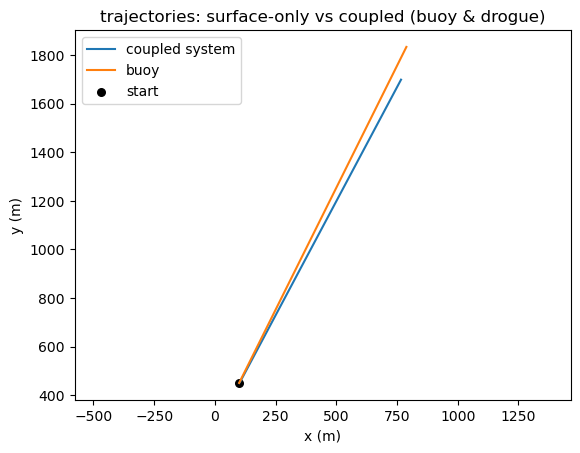

In [29]:
# Plot
plt.figure()
plt.plot(x_b_complete, y_b_complete, label="coupled system")
plt.plot(x_b_buoy, y_b_buoy, label="buoy")
plt.scatter([y0[0]], [y0[1]], s=30, label="start", color="k")
plt.axis("equal")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()
plt.title("trajectories: surface-only vs coupled (buoy & drogue)")
plt.show()